# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

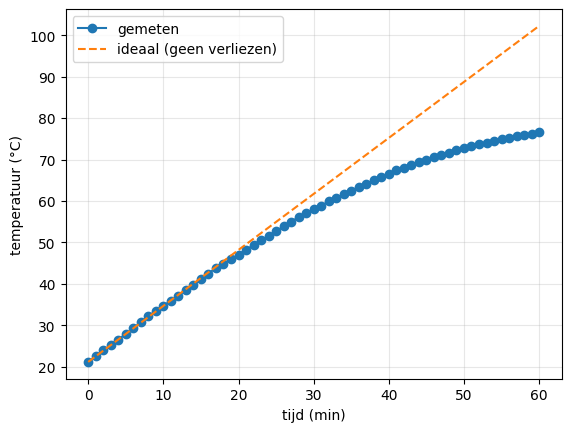

m_water_start = 472.1 g
m_water_eind  = 454.1 g
m_verdampt    = 18.0 g

E_in        = 216000 J
E_opwarming = 147679 J
E_verdamp   = 40680 J
verschil    = 27641 J


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# gegevens
m_beker_g = 820.8
m_start_g = 1292.9
m_eind_g  = 1274.9

m_w0 = (m_start_g - m_beker_g)/1000    # kg water start
m_w_end = (m_eind_g - m_beker_g)/1000  # kg water eind
m_evap = m_w0 - m_w_end                # kg verdwenen water

# aannames
c_w = 4186        # J/(kg K)
c_b = 840         # J/(kg K) (glas schatting)
m_b = m_beker_g/1000
L_v = 2.26e6      # J/kg
P = 60.0         # W

bestand = r"C:\Users\tim\Downloads\tempmetingen.csv"
t, T = np.genfromtxt(bestand, delimiter=";", skip_header=1, unpack=True, encoding="utf-8-sig")

t_s = t * 60  # minuten naar seconden

T0 = T[0]
C_tot = m_w0*c_w + m_b*c_b
T_ideal = T0 + (P * (t_s - t_s[0])) / C_tot

plt.figure()
plt.plot(t, T, "o-", label="gemeten")
plt.plot(t, T_ideal, "--", label="ideaal (geen verliezen)")
plt.xlabel("tijd (min)")
plt.ylabel("temperatuur (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

dT = T[-1] - T0
E_in = P * (t_s[-1] - t_s[0])
E_warm = C_tot * dT
E_evap = m_evap * L_v

print(f"m_water_start = {m_w0*1000:.1f} g")
print(f"m_water_eind  = {m_w_end*1000:.1f} g")
print(f"m_verdampt    = {m_evap*1000:.1f} g")
print()
print(f"E_in        = {E_in:.0f} J")
print(f"E_opwarming = {E_warm:.0f} J")
print(f"E_verdamp   = {E_evap:.0f} J")
print(f"verschil    = {E_in - (E_warm+E_evap):.0f} J")


## Aanbevelingen (verbetering experiment)

- **Meet het echte elektrische vermogen** van het verwarmingselement (met wattmeter óf door spanning en stroom tegelijk te meten). Dan wordt de energiebalans veel betrouwbaarder dan met een aangenomen waarde.

- **Beperk verdamping en warmteverlies** door een (doorzichtig) deksel met een klein gat voor de sensor/roerder te gebruiken en/of de maatbeker te isoleren (bijv. schuim, isolatiemantel). Hierdoor gaat een groter deel van de energie echt in het water.

- **Gebruik een beter “calorimeter”-vat**: een geïsoleerde beker (Dewar/thermos) of dubbele wand vermindert warmteverlies en maakt het proces beter vergelijkbaar met het ideale model.

- **Registreer omgevingscondities** (luchtstroming, kamertemperatuur) en zet de opstelling uit de tocht; convectie kan veel warmteverlies veroorzaken.

- **Meet meerdere keren** (replicaten) en vergelijk curves. Dat maakt het onderscheid tussen toevallige meetfout en systematische effecten (verdamping/verliezen) duidelijker.
